# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Agil Firli Gunawan
- Email: agilfirli29@gmail.com
- Id Dicoding: agilfirligunawan

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
# install library
!pip install shap xgboost imbalanced-learn -q

In [36]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import recall_score

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE


import warnings
warnings.filterwarnings('ignore')

### Menyiapkan data yang akan digunakan

In [3]:
dataset = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/refs/heads/main/employee/employee_data.csv"
df = pd.read_csv(dataset)

## Data Understanding

In [4]:
# Mengecek baris pertama
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [5]:
# Melihat Info Dataset
dataset = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [6]:
# Mengecek missing values pada setiap kolom
missing_values = df.isnull().sum()
missing_values

,0
EmployeeId,0
Age,0
Attrition,412
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


In [7]:
# Mengecek duplikat pada setiap kolom
duplicate_count = df.duplicated().sum()
print("Jumlah duplikasi: ", duplicate_count)

Jumlah duplikasi:  0


In [8]:
#Statistik Deskriptif
df.describe()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Insight:**
- Dataset terdiri dari 1470 baris dan 35 kolom.
- Tipe data terdiri dari numerik (int64, float64) dan kategorikal (object).
- **Terdapat 412 missing values pada kolom target `Attrition`.** Karena kita akan membuat model klasifikasi prediktif, baris dengan target yang kosong tidak dapat digunakan untuk melatih model. Oleh karena itu, baris ini harus dihapus pada tahap preprocessing.
- Tidak ada data duplikat dalam dataset ini.
- Terdapat beberapa kolom yang nilainya konstan (hanya satu nilai) seperti `EmployeeCount`, `StandardHours`, dan `Over18`. Kolom-kolom ini tidak memiliki variasi sehingga tidak akan berguna untuk model Machine Learning dan harus dihapus.

In [13]:
# Mempersiapkan data sementara khusus untuk visualisasi
df_eda = df.dropna(subset=['Attrition']).copy()
df_eda['Attrition'] = df_eda['Attrition'].astype(int)
df_eda['Attrition_Label'] = df_eda['Attrition'].map({0: 'Bertahan', 1: 'Resign'})

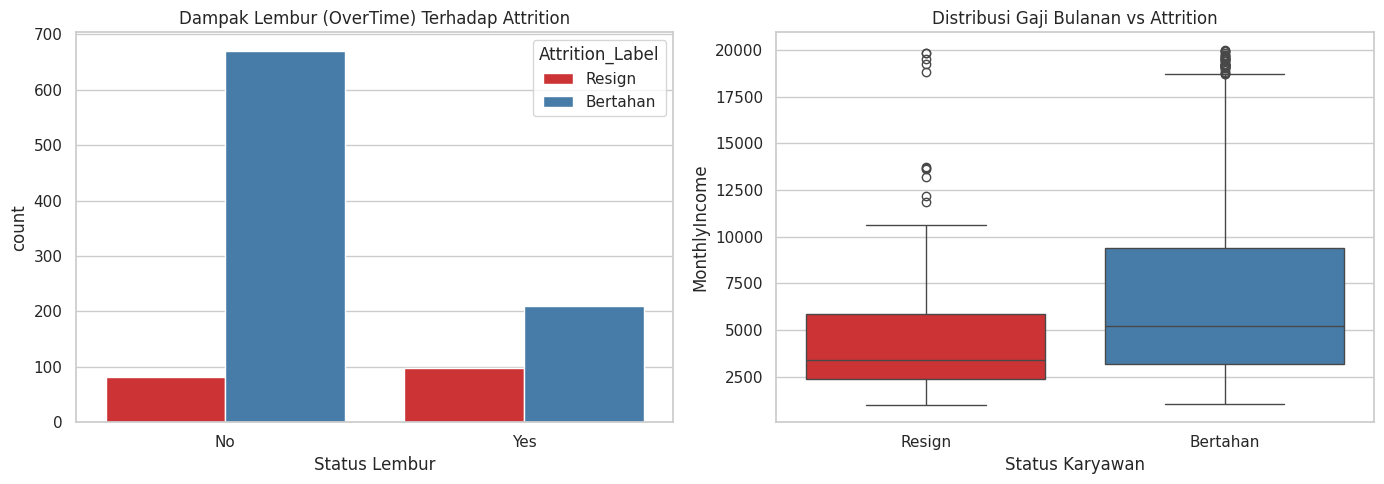

In [20]:
# Mulai Menggambar Visualisasi (Memenuhi Saran 1)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Attrition vs Lembur (OverTime)
sns.countplot(data=df_eda, x='OverTime', hue='Attrition_Label', palette='Set1', ax=axes[0])
axes[0].set_title('Dampak Lembur (OverTime) Terhadap Attrition')
axes[0].set_xlabel('Status Lembur')

# Plot 2: Attrition vs Gaji Bulanan (MonthlyIncome)
sns.boxplot(data=df_eda, x='Attrition_Label', y='MonthlyIncome', palette='Set1', ax=axes[1])
axes[1].set_title('Distribusi Gaji Bulanan vs Attrition')
axes[1].set_xlabel('Status Karyawan')

# Tampilkan grafik
plt.tight_layout()
plt.show()

## Data Preparation / Preprocessing

Membersihkan Data dan Ekspor untuk Dashboard (Sel Kode)

In [21]:
# Menghapus baris yang target Attrition-nya kosong & ubah ke integer
df_clean = df.dropna(subset=['Attrition']).copy()
df_clean['Attrition'] = df_clean['Attrition'].astype(int)

# Menghapus kolom yang nilainya konstan / tidak berguna
cols_to_drop = ['EmployeeId', 'EmployeeCount', 'StandardHours', 'Over18']
df_clean = df_clean.drop(columns=[col for col in cols_to_drop if col in df_clean.columns])

# Ekspor data bersih untuk Dashboard Metabase
df_clean.to_csv('cleaned_employee_data.csv', index=False)
print("Data bersih berhasil di-export menjadi 'cleaned_employee_data.csv'")

Data bersih berhasil di-export menjadi 'cleaned_employee_data.csv'


Memisahkan Target & Mengubah Teks Jadi Angka (Sel Kode)

In [22]:
# Pisahkan kolom Fitur (X) dan kolom Target/Label (y)
X = df_clean.drop(columns=['Attrition'])
y = df_clean['Attrition']

# One-Hot Encoding: Mengubah kolom teks (kategorikal) menjadi angka (0 dan 1)
X_encoded = pd.get_dummies(X, drop_first=True)
print(f"Jumlah kolom fitur setelah di-encoding: {X_encoded.shape[1]}")

Jumlah kolom fitur setelah di-encoding: 44


Normalisasi Skala Data & Pembagian Data

In [23]:
# Normalisasi data agar nilainya berada di rentang yang seragam (0 sampai 1)
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)

# Membagi data menjadi Data Latih (80%) dan Data Uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print("Data berhasil dibagi menjadi Train Set dan Test Set.")

Data berhasil dibagi menjadi Train Set dan Test Set.


Menyeimbangkan Data dengan SMOTE

In [24]:
# Mengatasi Imbalanced Data menggunakan SMOTE pada data latih
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Jumlah target Resign (1) SEBELUM SMOTE: {sum(y_train == 1)}")
print(f"Jumlah target Resign (1) SESUDAH SMOTE: {sum(y_train_smote == 1)}")

Jumlah target Resign (1) SEBELUM SMOTE: 143
Jumlah target Resign (1) SESUDAH SMOTE: 703


Jumlah target Resign (1) SEBELUM SMOTE: 143
Jumlah target Resign (1) SESUDAH SMOTE: 703



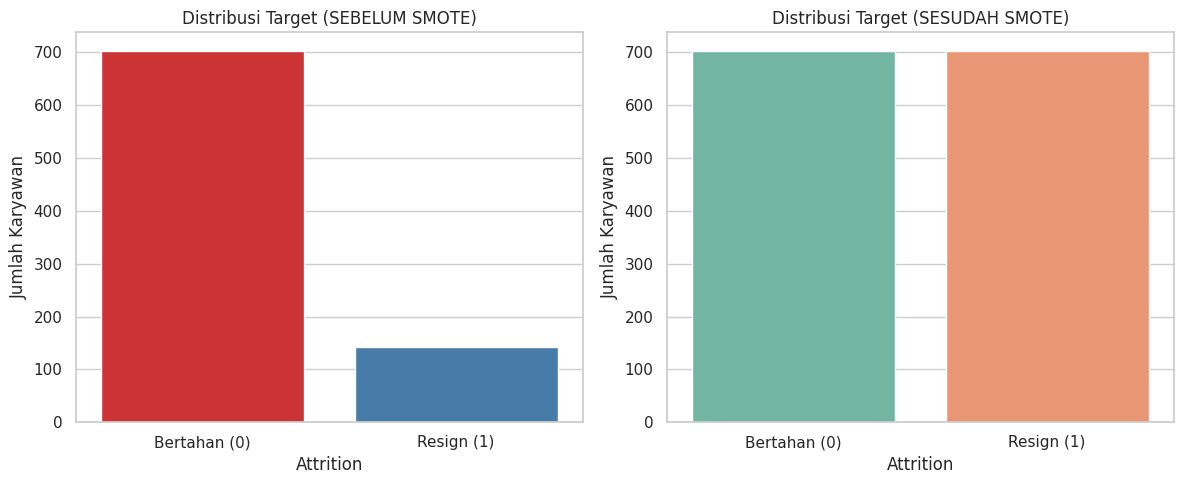

In [28]:
# Mengatasi Imbalanced Data menggunakan SMOTE pada data latih
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Jumlah target Resign (1) SEBELUM SMOTE: {sum(y_train == 1)}")
print(f"Jumlah target Resign (1) SESUDAH SMOTE: {sum(y_train_smote == 1)}\n")

# VISUALISASI EFEK SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Sebelum SMOTE
sns.countplot(x=y_train, palette='Set1', ax=axes[0])
axes[0].set_title('Distribusi Target (SEBELUM SMOTE)')
axes[0].set_xticklabels(['Bertahan (0)', 'Resign (1)'])
axes[0].set_ylabel('Jumlah Karyawan')

# Plot 2: Sesudah SMOTE
sns.countplot(x=y_train_smote, palette='Set2', ax=axes[1])
axes[1].set_title('Distribusi Target (SESUDAH SMOTE)')
axes[1].set_xticklabels(['Bertahan (0)', 'Resign (1)'])
axes[1].set_ylabel('Jumlah Karyawan')

plt.tight_layout()
plt.show()

## Modeling

=== Hasil Training & Komparasi Model ===
Logistic Regression -> Skor Recall: 0.75
Random Forest -> Skor Recall: 0.33
Support Vector Machine -> Skor Recall: 0.58
XGBoost -> Skor Recall: 0.50

 Model Terbaik: Logistic Regression (Recall: 0.75)


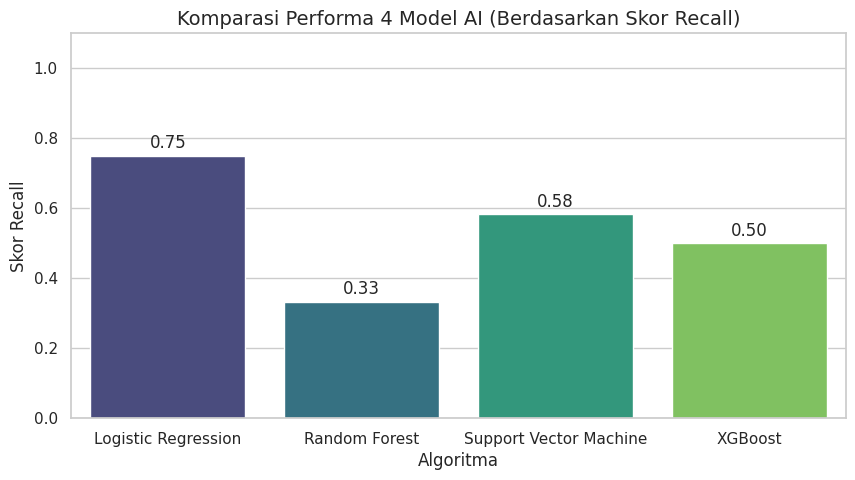

In [29]:
# Membandingkan >2 Model Machine Learning
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

best_model = None
best_recall = 0
best_model_name = ""

# Siapkan list kosong untuk menyimpan skor demi visualisasi
nama_model = []
skor_recall = []

print("=== Hasil Training & Komparasi Model ===")
for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)

    # Menghitung Recall
    recall = recall_score(y_test, y_pred)
    print(f"{name} -> Skor Recall: {recall:.2f}")

    # Simpan ke list
    nama_model.append(name)
    skor_recall.append(recall)

    # Mencari yang terbaik
    if recall > best_recall:
        best_recall = recall
        best_model = model
        best_model_name = name

print(f"\n Model Terbaik: {best_model_name} (Recall: {best_recall:.2f})")

# VISUALISASI KOMPARASI MODEL
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=nama_model, y=skor_recall, palette='viridis')
plt.title('Komparasi Performa 4 Model AI (Berdasarkan Skor Recall)', fontsize=14)
plt.ylabel('Skor Recall', fontsize=12)
plt.xlabel('Algoritma', fontsize=12)
plt.ylim(0, 1.1)

# Angka skor disetiap diagram batang
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.show()

## Evaluation

Laporan Evaluasi & Confusion Matrix

=== Laporan Evaluasi (Logistic Regression) ===

              precision    recall  f1-score   support

           0       0.93      0.72      0.81       176
           1       0.36      0.75      0.48        36

    accuracy                           0.73       212
   macro avg       0.64      0.74      0.65       212
weighted avg       0.84      0.73      0.76       212



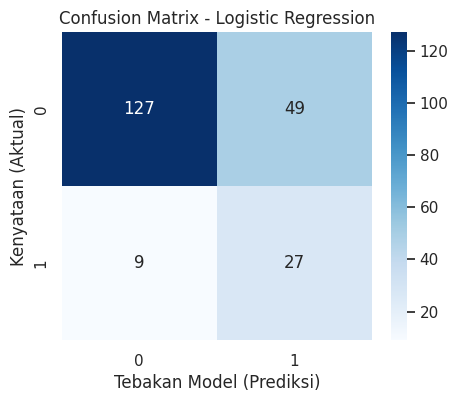

In [30]:
# Menampilkan Laporan Detail (Classification Report)
y_pred_best = best_model.predict(X_test)
print(f"=== Laporan Evaluasi ({best_model_name}) ===\n")
print(classification_report(y_test, y_pred_best))

# Menampilkan Confusion Matrix dengan visualisasi
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Tebakan Model (Prediksi)')
plt.ylabel('Kenyataan (Aktual)')
plt.show()

Analisis Alasan Resign dengan SHAP

Mengkalkulasi tingkat kepentingan fitur...


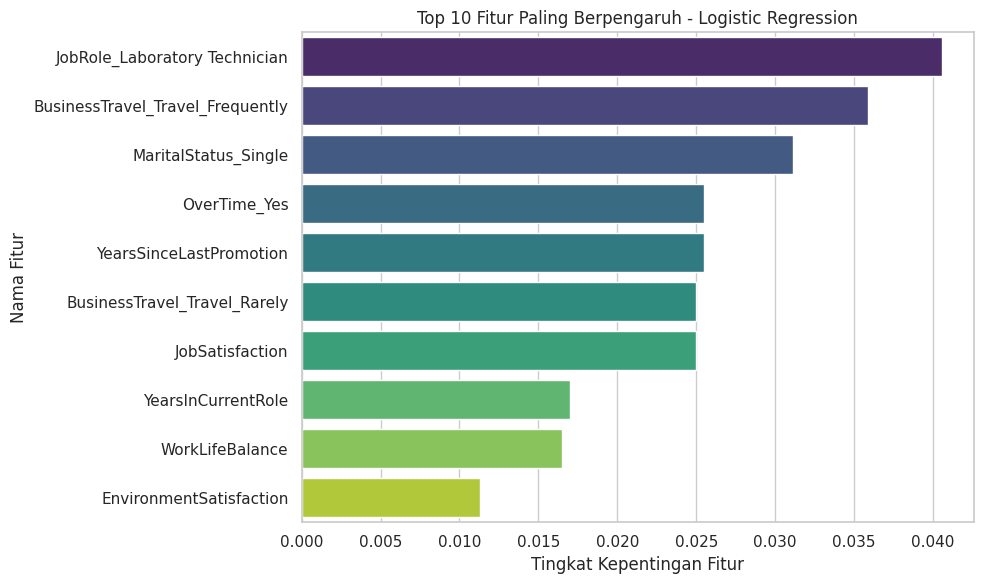

In [38]:
plt.figure(figsize=(10, 6))

# Skenario 1: Jika yang menang adalah XGBoost atau Random Forest (Bisa pakai SHAP)
if best_model_name in ['XGBoost', 'Random Forest']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    plt.title(f'Fitur Paling Berpengaruh Terhadap Prediksi Resign (SHAP) - {best_model_name}')

# Skenario 2: Jika yang menang adalah Logistic Regression atau SVM
else:
    print("Mengkalkulasi tingkat kepentingan fitur...")

    # Menggunakan Permutation Importance (Aman untuk Logistic Regression & SVM)
    result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)
    importances = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)

    # Menggambar Bar Chart
    sns.barplot(x=importances.values[:10], y=importances.index[:10], palette='viridis')
    plt.title(f'Top 10 Fitur Paling Berpengaruh - {best_model_name}')
    plt.xlabel('Tingkat Kepentingan Fitur')
    plt.ylabel('Nama Fitur')

# Menampilkan grafik
plt.tight_layout()
plt.show()

In [39]:
# Menyimpan model, scaler, dan urutan kolom untuk digunakan di prediction.py
joblib.dump(best_model, 'best_hr_model.pkl')
joblib.dump(scaler, 'hr_scaler.pkl')
joblib.dump(list(X_encoded.columns), 'hr_model_columns.pkl')

print("File Model ('best_hr_model.pkl') dan Scaler berhasil disimpan!")

File Model ('best_hr_model.pkl') dan Scaler berhasil disimpan!
